# Portugal’s Water Consumption Patterns (2011-2022)

Duda Costa Carvalho

This study aims to reveal regional differences in water use and provide insights for water management planning. The objective of this project is to identify spatial and temporal patterns in water consumption across Portuguese municipalities from 2011-2022 using the Self-Organizing Maps (SOMs) methodological approach. SOMs are an unsupervised ANN learning technique, used for high-dimensional data clustering by reducing it into 2D data. It preserves the typology by ensuring points close together remain close in the 2D grid.

Data:
- **Source:** PORDATA / Statistics Portugal
- **Spatial units:** 274 mainland municipalities
- **Time period:** 2011-2022 (12 annual observations)
- **Variable:** Water distributed/consumed per inhabitant (m³/hab)

## Spatial Clustering

In [1]:
# Install Somoclu
!pip install somoclu

Defaulting to user installation because normal site-packages is not writeable
--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1673, in print
    extend(render(renderable, render_options))
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1305, in render
    for render_output in iter_render:
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/segment.py", line 249, in split_lines
    for segment in segments:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1283, in render
    renderable = rich_cast(renderable)
  File 

In [2]:
# Install all libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
import somoclu

from numpy.ma.core import ceil
from scipy.spatial import distance #distance calculation
from sklearn.preprocessing import MinMaxScaler #normalisation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score #scoring
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib import animation, colors
import pandas as pd

import ipywidgets as widgets
from ipywidgets import interact, interactive, Layout
import glob

In [3]:
# Add a random seed for reproducibility
import numpy as np
np.random.seed(42)

# Load the data with correct encoding (UTF‑8)
# This is done because the data is in Portuguese, which contains special characters
data_file = "water_portugal_UPD.csv"
df = pd.read_csv(data_file, header=0, encoding='utf-8')

# Now, print results
print(df.head())

           Município  2011  2012  2013  2014  2015  2016  2017  2018  2019  \
0  Arcos de Valdevez  35.3  30.2  36.7  37.6  42.8  41.8  45.5  45.9  45.4   
1            Caminha  76.6  58.4  64.5  61.4  64.3  67.0  68.3  67.3  66.5   
2            Melgaço  41.6  29.8  36.2  39.0  43.5  51.0  45.3  46.2  45.5   
3             Monção  44.8  31.7  39.8  37.5  37.8  46.9  47.3  39.8  41.1   
4   Paredes de Coura  44.7  38.3  42.0  41.0  44.8  48.2  55.5  52.6  51.0   

   2020  2021  2022  
0  49.1  46.9  46.8  
1   NaN   NaN  46.8  
2  50.9  52.3  53.6  
3  43.0  53.7  68.2  
4  47.9  47.0  46.8  


### Exploratory Data Analysis (EDA)
Before SOM clustering, exploratory data analysis (EDA) was conducted to understand the overall distribution and patterns in the data. This included producing histograms for all years, a boxplot to understand the distribution of values and see outliers better.

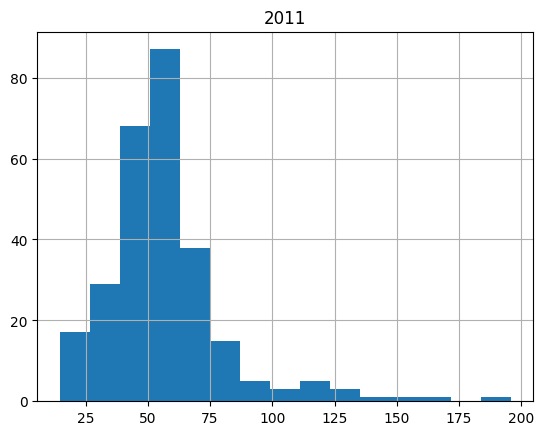

In [4]:
# Histogram
# Purpose: identify the median, data distribution, gaps and outliers
# 2011 was chosen as an example year
hist = df.hist(column='2011',bins = 15)

In [5]:
@widgets.interact (x = ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022'])
def histoplot (x = '2011'):
       df.hist(column = x, bins =15);

interactive(children=(Dropdown(description='x', options=('2011', '2012', '2013', '2014', '2015', '2016', '2017…

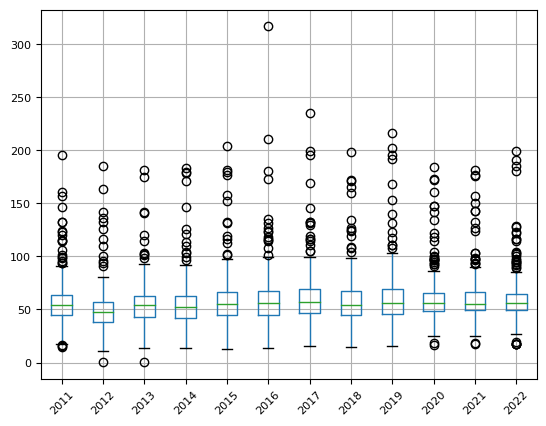

In [6]:
#Box plot
box=df.boxplot(fontsize = 8, rot = 45)

In [7]:
# Consumption per municipality
# How different are the outliers? What do the 'middle' consuption municipalities look like?

# Average across all years
df['avg_all_years'] = df[['2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022']].mean(axis=1)

# Top 10 highest average
print("TOP 10 HIGHEST CONSUMPTION MUNICIPALITIES (AVERAGE 2011-2022)")
top10 = df.nlargest(10, 'avg_all_years')[['Município', 'avg_all_years']]
print(top10)

# Bottom 10 lowest average
print("BOTTOM 10 LOWEST CONSUMPTION MUNICIPALITIES (AVERAGE 2011-2022)")
bottom10 = df.nsmallest(10, 'avg_all_years')[['Município', 'avg_all_years']]
print(bottom10)

# 'Middle' municipalities
# Sort by average consumption
sorted_munis = df.sort_values('avg_all_years')
total_munis = len(sorted_munis)
middle_start = total_munis // 2 - 2 # Two before median
middle_end = total_munis // 2 + 3 # Three after median

print("MIDDLE MUNICIPALITIES")
middle_munis = sorted_munis.iloc[middle_start:middle_end]
print(middle_munis.to_string(index=False))

TOP 10 HIGHEST CONSUMPTION MUNICIPALITIES (AVERAGE 2011-2022)
                      Município  avg_all_years
258                   Albufeira     196.475000
263                       Lagoa     177.766667
272               Vila do Bispo     170.283333
265                       Loulé     165.791667
261                Castro Marim     137.158333
264                       Lagos     131.733333
129                   Mangualde     127.850000
215                       Sines     120.025000
257                 Vila Viçosa     112.500000
273  Vila Real de Santo António     111.116667
BOTTOM 10 LOWEST CONSUMPTION MUNICIPALITIES (AVERAGE 2011-2022)
              Município  avg_all_years
54   Marco de Canaveses      15.475000
51              Cinfães      17.016667
30              Paredes      18.291667
50    Celorico de Basto      18.883333
34          Santo Tirso      23.266667
36                Trofa      23.641667
48                Baião      23.800000
20     Póvoa de Lanhoso      23.858333
24    

In [8]:
# Identify top and bottom municipalities
top_munis = ['Albufeira', 'Lagoa', 'Vila do Bispo']  
bottom_munis = ['Marco de Canaveses', 'Cinfães', 'Paredes']  
middle_munis = ['Soure', 'Cuba', 'Sobral de Monte Agraço']
all_featured = top_munis + bottom_munis + middle_munis

# Interactive plot 
def plot_municipality(municipio):
    if municipio in df['Município'].values:
        muni_data = df[df['Município'] == municipio].iloc[:, 1:13].T
        plt.figure(figsize=(10,5))
        plt.plot(muni_data.index, muni_data.values, marker='o', linewidth=2)
        plt.title(f'Water Consumption: {municipio} (2011-2022)')
        plt.xlabel('Year')
        plt.ylabel('m³ per capita')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Show average for context
        avg = df[df['Município'] == municipio]['avg_all_years'].values[0]
        print(f"Average consumption: {avg:.1f} m³")

# Create dropdown
interact(plot_municipality, municipio=widgets.Dropdown(options=all_featured, description='Municipality:'));

interactive(children=(Dropdown(description='Municipality:', options=('Albufeira', 'Lagoa', 'Vila do Bispo', 'M…

### Linear Interpolation & Data Normalization
While looking at the raw data, some missing values were identified. Sixteen municipalities had a single missing year, either 2020 or 2021. These were filled using linear interpolation below, which estimated missing values based on neighboring years. 
To enable fair comparison of temporal consumption patterns across municipalities with vastly different absolute water usage, a global Min‑Max normalization was applied after interpolation. Every data point was rescaled within the 0-1 range. 

In [9]:
# Data Normalization
# Start with raw numeric data
year_columns = ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']
df_numeric = df[year_columns]

# Interpolate missing values
df_interpolated = df_numeric.interpolate(method='linear', axis=1)

# Check if any NaNs remain at edges (first or last year)
if df_interpolated['2011'].isnull().any():
    df_interpolated = df_interpolated.bfill(axis=1)  # backfill
if df_interpolated['2022'].isnull().any():
    df_interpolated = df_interpolated.ffill(axis=1)  # forward fill

# Normalize using MaxMin
def global_minmax_scaler(data):
    """Scale all data using global min and max"""
    global_min = data.min().min()  # Find single min across all data
    global_max = data.max().max()  # Find single max across all data
    scaled = (data - global_min) / (global_max - global_min)
    return scaled, global_min, global_max

# Apply global scaling
df_norm, global_min, global_max = global_minmax_scaler(df_interpolated)
df_norm = pd.DataFrame(df_norm, index=df.index, columns=year_columns)

# Verify no NaNs remain
print("Any NaNs after interpolation + normalization?", df_norm.isnull().any().any())

Any NaNs after interpolation + normalization? False


In [10]:
# Check if all values are between 0 and 1:
print("Range Check")
print(f"Min value: {df_norm.min().min():.3f}")
print(f"Max value: {df_norm.max().max():.3f}")

Range Check
Min value: 0.000
Max value: 1.000


### Raw vs. Normalized Consumption Data
This was done to illustrate the extreme range of values in the dataset, and to demonstrate the importance of normalization for pattern clustering. 

In [11]:
# Prepare index
df_original = pd.read_csv('water_portugal_UPD.csv', encoding='utf-8')
municipio_names = df_original['Município'].values[:274]

df_norm.index = municipio_names

<function matplotlib.pyplot.show(close=None, block=None)>

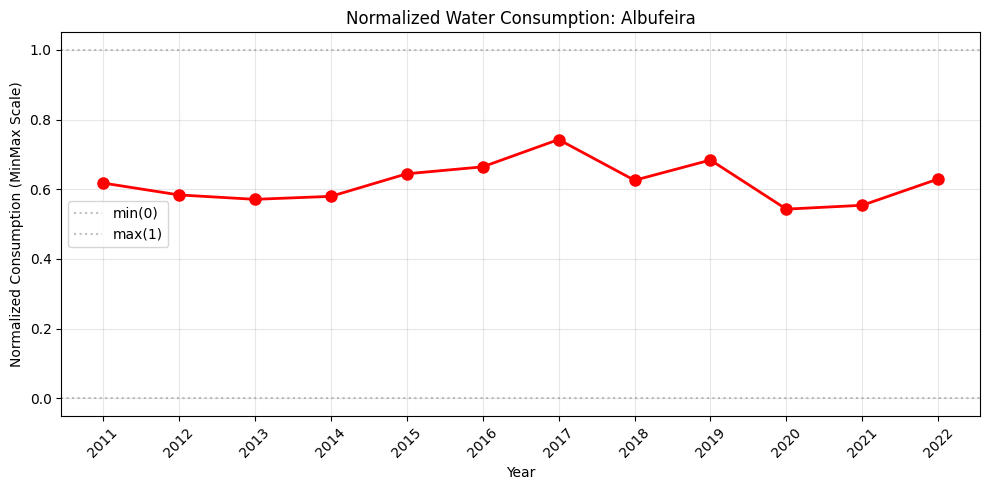

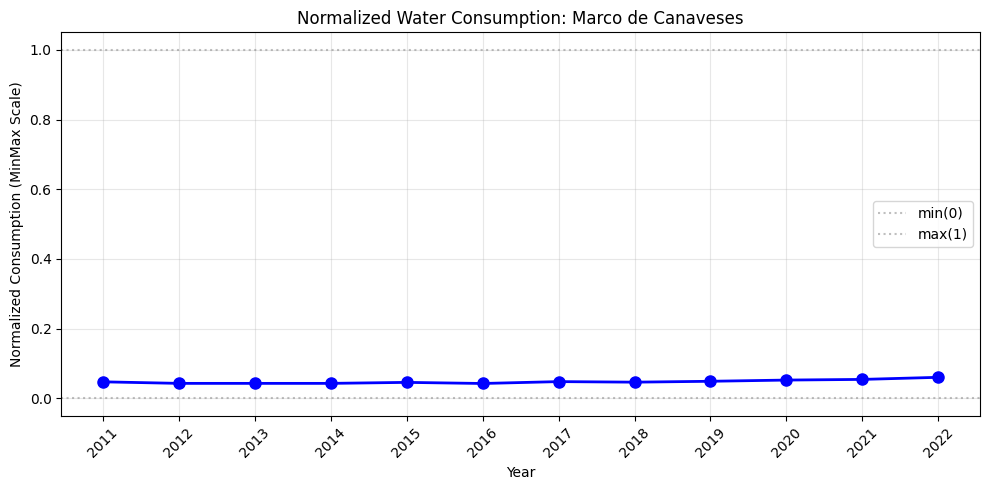

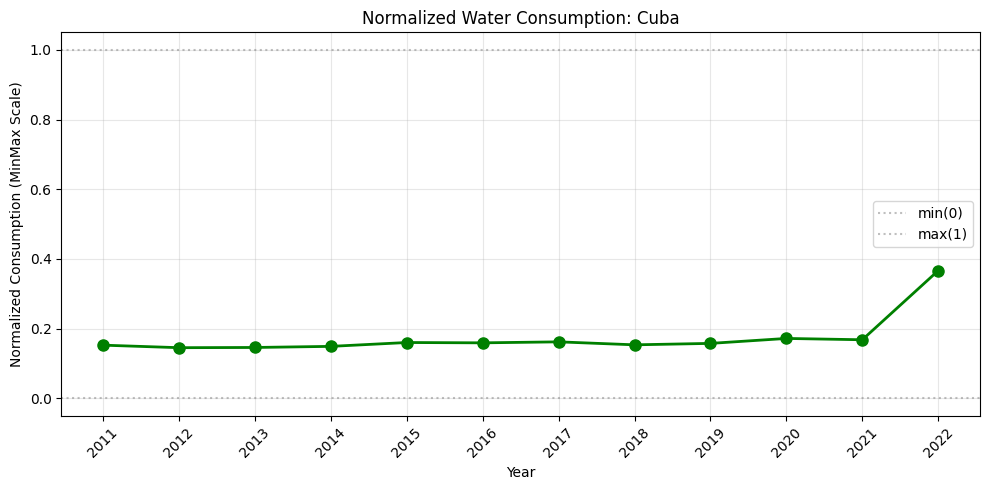

In [12]:
# Normalized Comparison (Albufeira, Marco de Canaveses and Cuba)
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np

years = ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']

# Find positions
munis_list = list(df_norm.index)
albufeira_pos = munis_list.index('Albufeira')
marco_pos = munis_list.index('Marco de Canaveses')
cuba_pos = munis_list.index('Cuba')

albufeira_norm = df_norm.iloc[albufeira_pos].values
marco_norm = df_norm.iloc[marco_pos].values
cuba_norm = df_norm.iloc[cuba_pos].values

# Plot normalized values
plt.figure(figsize=(10,5))
plt.plot(years, albufeira_norm, 'r-o', linewidth=2, markersize=8)
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='min(0)')
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='max(1)')
plt.title('Normalized Water Consumption: Albufeira')
plt.xlabel('Year')
plt.ylabel('Normalized Consumption (MinMax Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

plt.figure(figsize=(10,5))
plt.plot(years, marco_norm, 'b-o', linewidth=2, markersize=8)
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='min(0)')
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='max(1)')
plt.title('Normalized Water Consumption: Marco de Canaveses')
plt.xlabel('Year')
plt.ylabel('Normalized Consumption (MinMax Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

plt.figure(figsize=(10,5))
plt.plot(years, cuba_norm, 'g-o', linewidth=2, markersize=8)
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='min(0)')
plt.axhline(y=1, color='gray', linestyle=':', alpha=0.5, label='max(1)')
plt.title('Normalized Water Consumption: Cuba')
plt.xlabel('Year')
plt.ylabel('Normalized Consumption (MinMax Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

### SOM Training

In [13]:
# Select number of rows and columns (in this case, I selected 7x7 after testing different lattice sizes)
rowsnum = widgets.IntSlider()
columnum = widgets.IntSlider()

display (rowsnum)
display (columnum)

IntSlider(value=0)

IntSlider(value=0)

In [16]:
# Train the SOM
data = np.float32(df_norm)
som = somoclu.Somoclu(n_columns = columnum.value, n_rows = rowsnum.value, data=data, compactsupport=False)
%time som.train()

CPU times: user 128 ms, sys: 8.96 ms, total: 137 ms
Wall time: 28.8 ms


### U-Matrix
The U-Matrix visualizes the distance between neighboring neurons. It contains dots, which represent neurons, and numbers that represent a stack of labels.

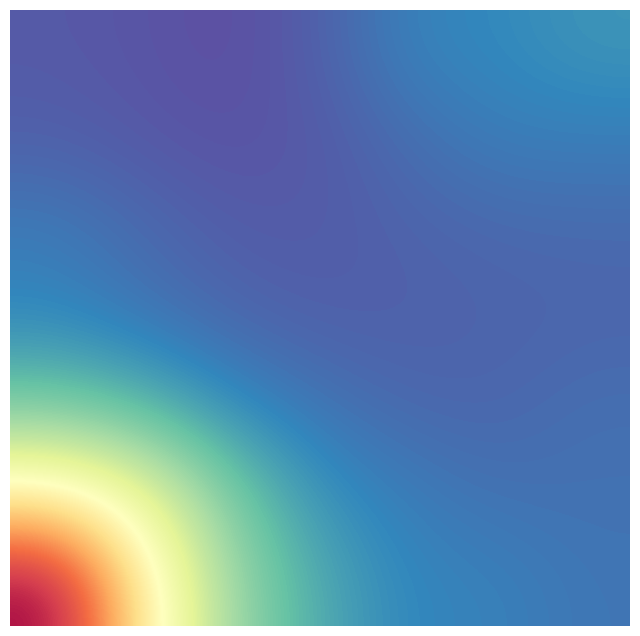

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.8/dist-packages/matplotlib/pyplot.py'>

In [17]:
#SOM
som.view_umatrix()

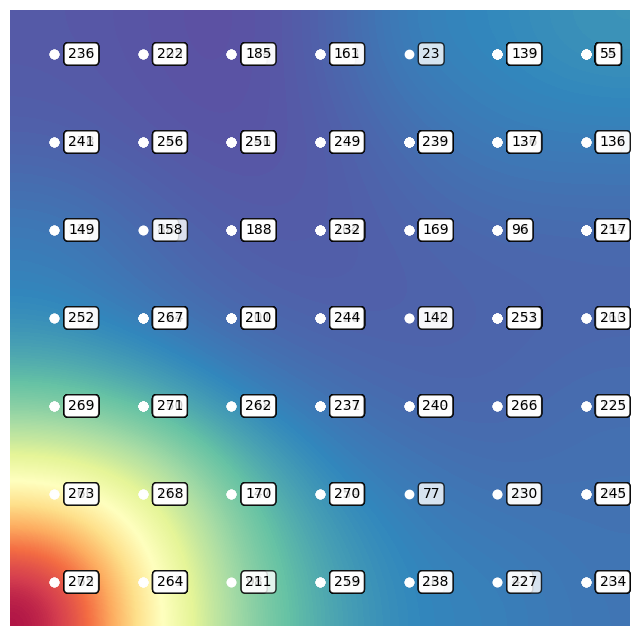

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.8/dist-packages/matplotlib/pyplot.py'>

In [18]:
# This step shows the U-Matrix with the labels (numbers) of the rows of our input data mapped on top
labels = range(274)
som.view_umatrix(bestmatches=True, labels=labels)

After running SOM, let's run diagnostics to see how many of the 49 neurons were utilized:

In [19]:
# Run Diagnostics
print("Diagnostics")
print(f"Number of municipalities: {len(df)}")
print(f"SOM grid: {rowsnum.value}×{columnum.value} = {rowsnum.value * columnum.value} neurons")

# Check bmus
if hasattr(som, 'bmus'):
    print(f"\nbmus shape: {som.bmus.shape}")
    print(f"bmus min row: {som.bmus[:,0].min()}, max row: {som.bmus[:,0].max()}")
    print(f"bmus min col: {som.bmus[:,1].min()}, max col: {som.bmus[:,1].max()}")
    
# Count municipalities per neuron
    from collections import Counter
    bmus_tuples = [tuple(bmu) for bmu in som.bmus]
    neuron_counts = Counter(bmus_tuples)
    print(f"\nNeurons used: {len(neuron_counts)} out of {rowsnum.value * columnum.value}")
    print(f"Top 5 most populated neurons: {neuron_counts.most_common(5)}")
else:
    print("No bmus attribute found - SOM may not be trained properly")

Diagnostics
Number of municipalities: 274
SOM grid: 7×7 = 49 neurons

bmus shape: (274, 2)
bmus min row: 0, max row: 6
bmus min col: 0, max col: 6

Neurons used: 49 out of 49
Top 5 most populated neurons: [((6, 0), 15), ((6, 2), 14), ((4, 1), 12), ((5, 0), 11), ((1, 4), 10)]


### Elbow Method

The Elbow Method was chosen to find the optimal k for secondary clustering. The code/ plot is seen below:

Original shape: (7, 7, 12)
Original type: <class 'numpy.ndarray'>
Method 1 shape: (49, 12)
Method 1 dimensions: 2

Running KMeans...


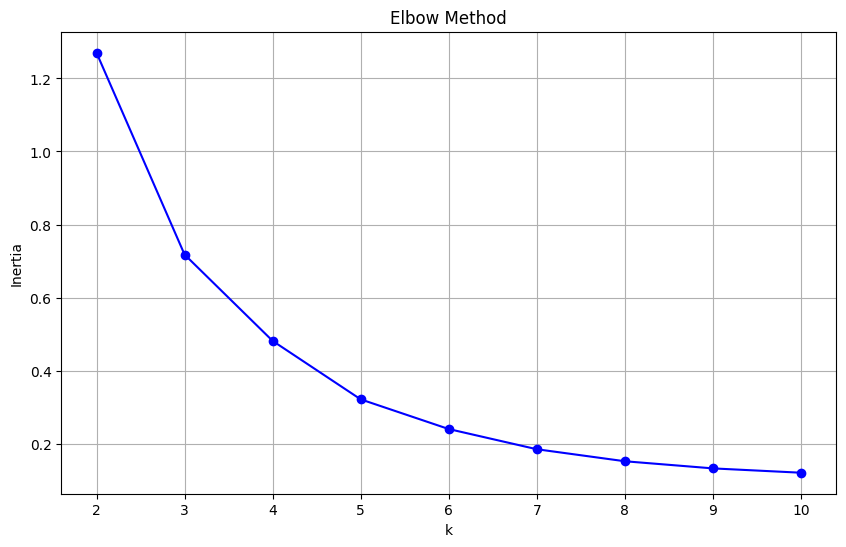

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Get the codebook
codebook = som.codebook
print(f"Original shape: {codebook.shape}")
print(f"Original type: {type(codebook)}")

# The data is in 3D. Let's reshape:
try:
    # Method: Direct reshape
    codebook_2d = codebook.reshape(49, 12)
    print(f"Method 1 shape: {codebook_2d.shape}")
    print(f"Method 1 dimensions: {codebook_2d.ndim}")
except Exception as e:
    print(f"Method 1 failed: {e}")

# KMeans 
if 'codebook_2d' in locals() and codebook_2d.ndim == 2:
    print("\nRunning KMeans...")
    inertias = []
    k_values = range(2, 11)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(codebook_2d)
        inertias.append(kmeans.inertia_)
    
# Plot
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, inertias, 'bo-')
    plt.xlabel('k')
    plt.ylabel('Inertia')
    plt.title('Elbow Method')
    plt.grid(True)
    plt.show()
else:
    print("Could not create 2D array")

### Silhouette Score

As seen above, the Elbow Method showed a smooth decrease in inertia, without a clear inflection point. Therefore, another approach was taken, in this case the Silhouette Score. Here, scores calculated k=2, 3, 4, ... k=10.

k=2: silhouette score =  0.684
k=3: silhouette score =  0.403
k=4: silhouette score =  0.396
k=5: silhouette score =  0.376
k=6: silhouette score =  0.326
k=7: silhouette score =  0.342
k=8: silhouette score =  0.313
k=9: silhouette score =  0.281
k=10: silhouette score =  0.276
Best k by silhouette score: 2


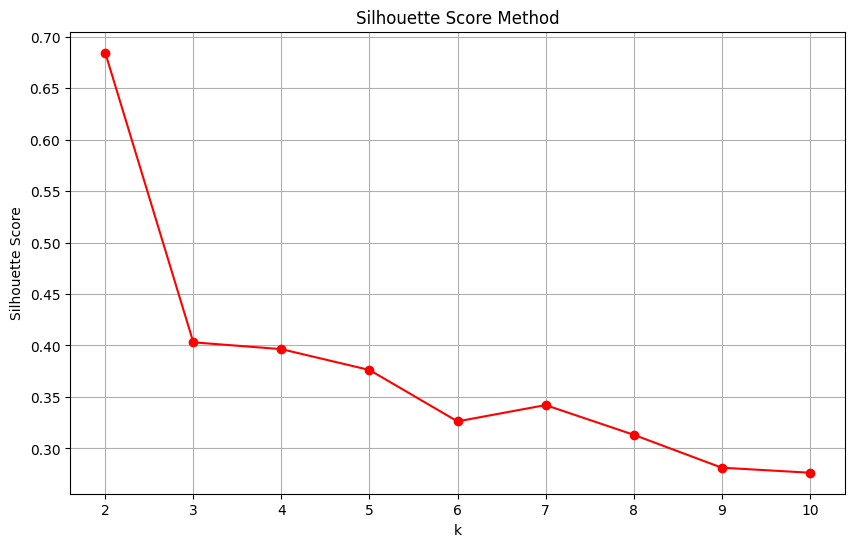

In [21]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores from k=2 ... k=10
silhouette_scores = []
k_range = range(2,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(codebook_2d)
    score = silhouette_score(codebook_2d, cluster_labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score: .3f}")

# Find best k
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Best k by silhouette score: {best_k}")

#Plot 
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.grid(True)
plt.show()

Even though the best k by silhouette score = 2, k=5 was chosen for secondary clustering for interpretability. It allows for the identification of other meaningful clusters that would have been hidden at k=2.

### Secondary Clustering
During this step, each municipality in the dataset got a Best Matching Unit (BMU). After this, an updated csv file containing all municipalities, 2011-2022 data, and the cluster assignments will be generated.

In [22]:
# Cluster and plot the nodes of the SOM
km = KMeans(n_clusters=5)
som.cluster(km)
node_cl= som.clusters
print(node_cl)

[[0 0 0 0 3 3 3]
 [0 0 0 0 3 3 3]
 [4 0 0 0 0 3 3]
 [4 4 0 0 0 0 0]
 [4 4 4 4 0 0 0]
 [2 2 4 4 4 0 0]
 [1 2 2 4 4 4 4]]


In [23]:
# Get the best matching unit (bm) from the SOM
bm = som.bmus

# assign the clusters to each row in input data
cluster_ids = []
for i in range(len(bm)):
  cluster_ids.append(som.clusters[som.bmus[i, 1], som.bmus[i, 0]])
#print a list with clusters_ids
print (cluster_ids)

[3, 0, 3, 3, 3, 3, 3, 0, 0, 0, 3, 3, 0, 0, 4, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 0, 3, 0, 0, 3, 3, 4, 0, 3, 3, 0, 3, 3, 3, 3, 0, 4, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 4, 3, 3, 0, 3, 0, 0, 4, 3, 0, 3, 0, 4, 0, 4, 0, 4, 4, 0, 0, 0, 2, 4, 4, 4, 3, 3, 0, 0, 0, 0, 0, 3, 3, 3, 3, 0, 2, 4, 0, 0, 0, 0, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 4, 0, 0, 0, 0, 0, 0, 4, 0, 0, 3, 3, 3, 2, 0, 3, 3, 3, 3, 3, 3, 3, 4, 3, 4, 2, 0, 4, 4, 3, 4, 4, 4, 4, 0, 3, 4, 0, 3, 0, 0, 4, 0, 0, 0, 0, 4, 4, 0, 0, 0, 0, 4, 0, 4, 4, 2, 0, 0, 4, 0, 4, 0, 0, 0, 0, 0, 4, 0, 0, 0, 4, 0, 0, 0, 4, 0, 0, 0, 0, 4, 0, 0, 4, 0, 0, 4, 4, 0, 0, 4, 4, 0, 4, 0, 2, 2, 0, 4, 2, 4, 3, 4, 0, 4, 4, 0, 0, 4, 0, 3, 4, 0, 0, 0, 0, 0, 0, 4, 0, 0, 4, 4, 3, 0, 0, 4, 0, 0, 0, 0, 4, 4, 0, 4, 0, 4, 0, 4, 4, 0, 2, 1, 4, 2, 2, 4, 1, 2, 1, 0, 4, 2, 4, 4, 4, 1, 2]


In [24]:
# Add cluster labels as a new column
df['Cluster'] = cluster_ids

# Remove the old column if it exists
if 0 in df.columns:
    df.drop(columns=[0], inplace=True)

# Save to CSV
df.to_csv('water_SOM_UTF.csv', index=False, encoding='utf-8-sig')

In [25]:
import pandas as pd

# Load the files
clusters = pd.read_csv('water_SOM_UTF.csv')
raw = pd.read_csv('water_portugal_UPD.csv', encoding='utf-8')

# Merge on municipality name (adjust column names as needed)
merged = pd.merge(raw, clusters, on='Município', how='inner')

# Check if any rows were lost
print(f"Raw rows: {len(raw)}, Merged rows: {len(merged)}")

# Average per cluster
cluster_avg = merged.groupby('Cluster').mean(numeric_only=True)
cluster_avg['Overall_Avg'] = cluster_avg.mean(axis=1)
print(cluster_avg[['Overall_Avg']].sort_values('Overall_Avg'))

Raw rows: 274, Merged rows: 274
         Overall_Avg
Cluster             
3          36.119420
0          54.766621
4          69.776617
2         107.857675
1         177.579167


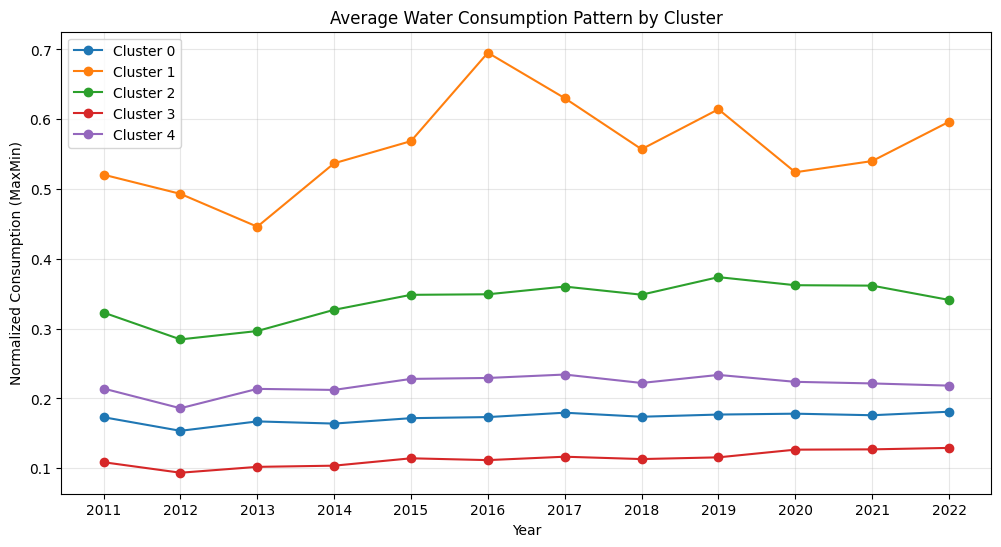

In [26]:
# Add cluster labels to normalized data
df_norm['Cluster'] = cluster_ids
years = ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022']

# Plot average pattern for each cluster
plt.figure(figsize=(12,6))
for cluster in range(5):
    cluster_data = df_norm[df_norm['Cluster'] == cluster].iloc[:, :12].mean()
    plt.plot(years, cluster_data.values, marker='o', label=f'Cluster {cluster}')

plt.title('Average Water Consumption Pattern by Cluster')
plt.xlabel('Year')
plt.ylabel('Normalized Consumption (MaxMin)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Now there is a file titled "water_SOM_UTF". I liked this file back to the Portugal municipalities shapefile I obtained from the Living Atlas in ArcGIS Pro, to see if there are any spatial clusters. With that, I created a choropleth map to show the clusters.

## Temporal Clustering
In addition to clustering municipalities by their consumption patterns, the data were transposed to investigate potential temporal groupings. The same normalized dataset from the previous spatial clustering was taken to create a 12 (years) x 274 (municipalities) sheet. 

In [27]:
# Install Somoclu
!pip install somoclu
import somoclu

Defaulting to user installation because normal site-packages is not writeable
--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1673, in print
    extend(render(renderable, render_options))
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1305, in render
    for render_output in iter_render:
  File "/usr/local/lib/python3.8/dist-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/segment.py", line 249, in split_lines
    for segment in segments:
  File "/usr/local/lib/python3.8/dist-packages/pip/_vendor/rich/console.py", line 1283, in render
    renderable = rich_cast(renderable)
  File 

In [28]:
# Confirm the data was transposed correctly
print("TEMPORAL CLUSTERING ANALYSIS")

# Set random seed for reproducibility
import numpy as np
np.random.seed(42)

# Define year columns explicitly
year_columns = ['2011', '2012', '2013', '2014', '2015', '2016', 
                '2017', '2018', '2019', '2020', '2021', '2022']

# Select ONLY the year columns
df_years_only = df_norm[year_columns]
print(f"Years-only data shape: {df_years_only.shape} (should be 274, 12)")

# Transpose the correct data
# Rows = years (12), Columns = municipalities (274)
df_time = df_years_only.T
data_time = np.float32(df_time.values)
print(f"Transposed data shape: {df_time.shape} (years × municipalities)")

TEMPORAL CLUSTERING ANALYSIS
Years-only data shape: (274, 12) (should be 274, 12)
Transposed data shape: (12, 274) (years × municipalities)


In [29]:
# Train the SOM
time_som = somoclu.Somoclu(n_columns=3, n_rows=3, data=data_time)
time_som.train()

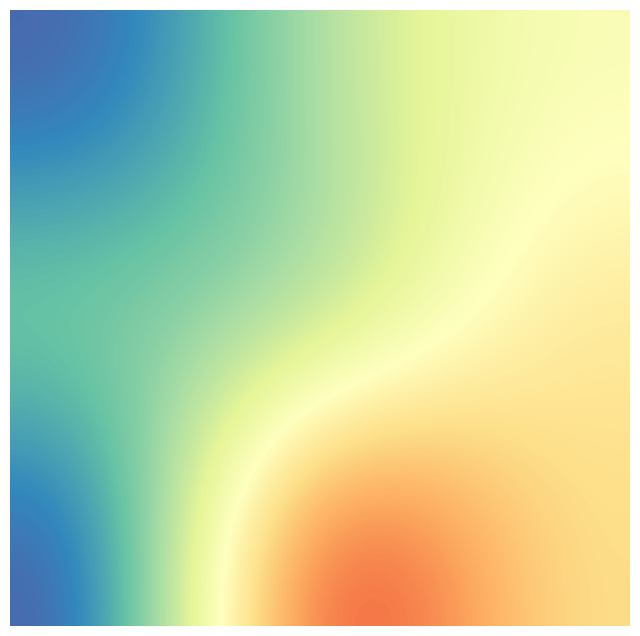

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.8/dist-packages/matplotlib/pyplot.py'>

In [30]:
# Visualize U-matrix for years
time_som.view_umatrix()

### Elbow Method
Before secondary clustering, the elbow method was applied to the temporal SOM codebook. Although the number of neurons is small, the method is appropriate because it evaluates the reduction in within-cluster variance. 

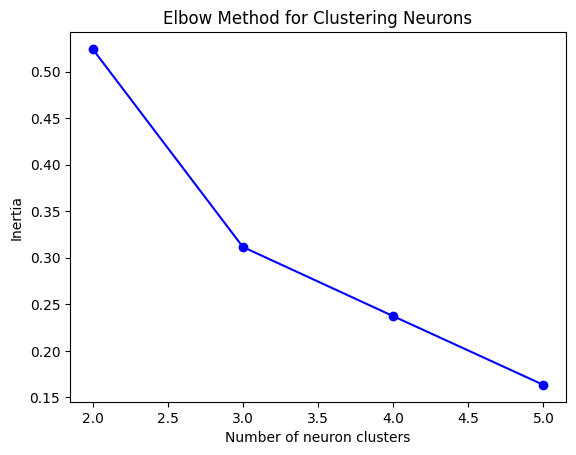

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Get the codebook (9 neurons × 274 municipalities)
codebook = time_som.codebook.reshape(9, 274)

# Try different numbers of clusters (k from 2 to 5)
inertias = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(codebook)
    inertias.append(kmeans.inertia_)

# Plot elbow
plt.plot(range(2,6), inertias, 'bo-')
plt.xlabel('Number of neuron clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Clustering Neurons')
plt.show()

In [32]:
# Run Diagnostics
print("Diagnostics")

# Define SOM grid dimensions
rowsnum_t = 3  # n_rows from your SOM
columnum_t = 3  # n_columns from your SOM

print(f"SOM grid: {rowsnum_t}×{columnum_t} = {rowsnum_t * columnum_t} neurons")

# Check bmus
if hasattr(time_som, 'bmus'):
    print(f"\nbmus shape: {time_som.bmus.shape}")
    print(f"bmus min row: {time_som.bmus[:,0].min()}, max row: {time_som.bmus[:,0].max()}")
    print(f"bmus min col: {time_som.bmus[:,1].min()}, max col: {time_som.bmus[:,1].max()}")
    
# Count municipalities per neuron
    from collections import Counter
    bmus_tuples_t = [tuple(bmu) for bmu in time_som.bmus]
    neuron_counts_t = Counter(bmus_tuples_t)
    print(f"\nNeurons used: {len(neuron_counts_t)} out of {rowsnum_t * columnum_t}")
    print(f"Top 5 most populated neurons: {neuron_counts_t.most_common(5)}")
else:
    print("No bmus attribute found - SOM may not be trained properly")

Diagnostics
SOM grid: 3×3 = 9 neurons

bmus shape: (12, 2)
bmus min row: 0, max row: 2
bmus min col: 0, max col: 2

Neurons used: 7 out of 9
Top 5 most populated neurons: [((0, 1), 3), ((2, 1), 2), ((0, 0), 2), ((1, 0), 2), ((2, 2), 1)]


In [33]:
from sklearn.cluster import KMeans

# Run k-means with k=4 (elbow result)
kmeans_neurons = KMeans(n_clusters=4, random_state=42)
neuron_clusters = kmeans_neurons.fit_predict(codebook)  # array of length 9, values 0,1,2,3

In [34]:
# Print neuron clusters
for neuron_idx in range(9):
    row = neuron_idx // 3
    col = neuron_idx % 3
    print(f"Neuron ({row},{col}) -> Cluster {neuron_clusters[neuron_idx]}")

Neuron (0,0) -> Cluster 1
Neuron (0,1) -> Cluster 1
Neuron (0,2) -> Cluster 0
Neuron (1,0) -> Cluster 1
Neuron (1,1) -> Cluster 1
Neuron (1,2) -> Cluster 0
Neuron (2,0) -> Cluster 1
Neuron (2,1) -> Cluster 2
Neuron (2,2) -> Cluster 3


In [35]:
year_clusters = []

print("\nYear assignments to clusters:")
for i, year in enumerate(df_time.index):          
    row, col = time_som.bmus[i]                   
    neuron_idx = row * 3 + col                     
    cluster_id = neuron_clusters[neuron_idx]       
    year_clusters.append(cluster_id)
    print(f"{year}: Neuron ({row},{col}) -> Cluster {cluster_id}")


Year assignments to clusters:
2011: Neuron (2,1) -> Cluster 2
2012: Neuron (2,2) -> Cluster 3
2013: Neuron (1,2) -> Cluster 0
2014: Neuron (2,1) -> Cluster 2
2015: Neuron (2,0) -> Cluster 1
2016: Neuron (0,0) -> Cluster 1
2017: Neuron (1,0) -> Cluster 1
2018: Neuron (1,0) -> Cluster 1
2019: Neuron (0,1) -> Cluster 1
2020: Neuron (0,1) -> Cluster 1
2021: Neuron (0,1) -> Cluster 1
2022: Neuron (0,0) -> Cluster 1


In [36]:
# Create a dictionary: cluster -> list of years
from collections import defaultdict
clusters_dict = defaultdict(list)

for year, cluster in zip(df_time.index, year_clusters):
    clusters_dict[cluster].append(year)

print("\n=== FINAL TEMPORAL CLUSTERS (k=4) ===")
for cluster in sorted(clusters_dict.keys()):
    years = clusters_dict[cluster]
    print(f"Cluster {cluster}: {', '.join(years)}")


=== FINAL TEMPORAL CLUSTERS (k=4) ===
Cluster 0: 2013
Cluster 1: 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022
Cluster 2: 2011, 2014
Cluster 3: 2012


In [37]:
# Drop the 'Cluster' column from the years
df_norm = df_norm.drop(columns=['Cluster'])   # or whatever the column is called

In [38]:
# Consumption patterns
import pandas as pd
import numpy as np

# Create a dataframe with years as rows and cluster labels
cluster_info = pd.DataFrame({
    'year': df_norm.columns,
    'cluster': year_clusters
})

#For each cluster, compute the average across all municipalities for those years
cluster_means = {}
for c in sorted(cluster_info['cluster'].unique()):
    years_in_cluster = cluster_info[cluster_info['cluster'] == c]['year']
    # average over those years (across municipalities)
    cluster_means[c] = df_norm[years_in_cluster].mean(axis=1).mean()

print("Average normalized consumption per cluster:")
for c, val in cluster_means.items():
    print(f"Cluster {c}: {val:.3f}")

Average normalized consumption per cluster:
Cluster 0: 0.172
Cluster 1: 0.189
Cluster 2: 0.177
Cluster 3: 0.158


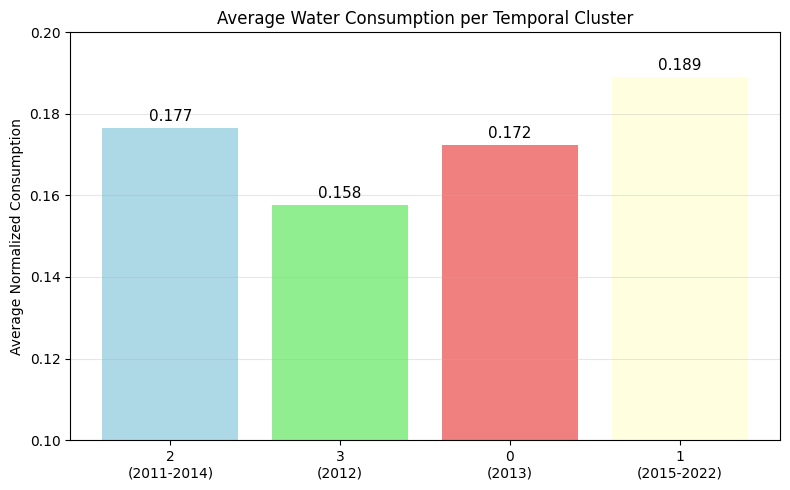

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize clusters
cluster_ranges = {}
for c in cluster_info['cluster'].unique():
    years = cluster_info[cluster_info['cluster'] == c]['year'].astype(int)
    cluster_ranges[c] = (years.min(), years.max())

# Sort clusters chronologically
sorted_clusters = sorted(cluster_ranges.keys(), key=lambda c: cluster_ranges[c][0])

# Build labels and averages
clusters = []
averages = []
for c in sorted_clusters:
    min_y, max_y = cluster_ranges[c]
    if min_y == max_y:
        label = f"{c}\n({min_y})"
    else:
        label = f"{c}\n({min_y}-{max_y})"
    clusters.append(label)
    averages.append(cluster_means[c])
    
# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(clusters, averages, color=['lightblue', 'lightgreen', 'lightcoral', 'lightyellow'])

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.3f}', ha='center', va='bottom', fontsize=11)

plt.ylabel('Average Normalized Consumption')
plt.title('Average Water Consumption per Temporal Cluster')
plt.ylim(0.10, 0.20)  # adjust to make differences visible
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Trajectory Analysis
To comprehend spatial and temporal patterns together, I overlaid the four temporal clusters over the three municipalities analyzed in the spatial clustering section.

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

cluster_colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']

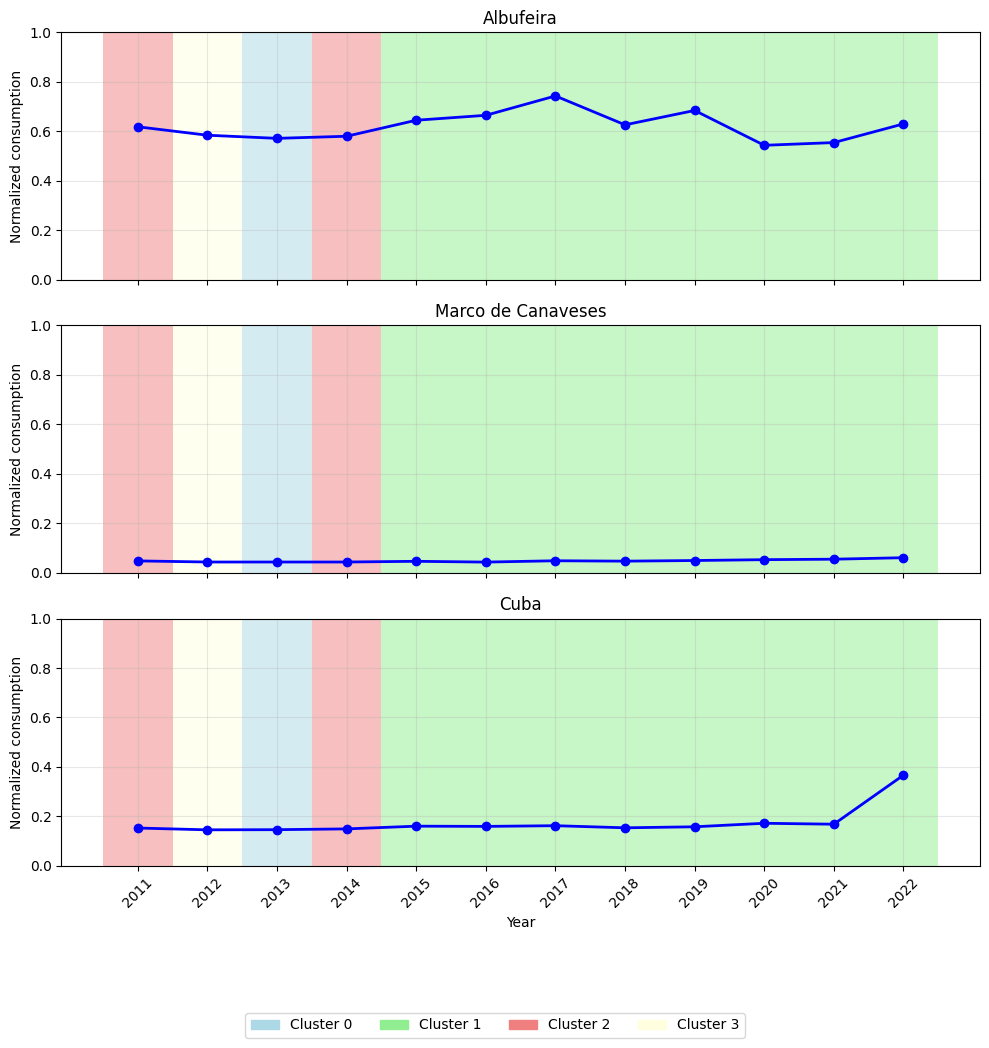

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Setup
years = ['2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022']
cluster_colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']  # adjust number if k≠4

# Municipalities to plot
municipalities = ['Albufeira', 'Marco de Canaveses', 'Cuba']
muni_data = df_norm.loc[municipalities]  # should be (3,12)

# Create subplots with more vertical space
fig, axes = plt.subplots(len(municipalities), 1, figsize=(10, 10), sharex=True)

for ax, muni in zip(axes, municipalities):
    values = muni_data.loc[muni].values
    
    # Plot line
    ax.plot(range(12), values, 'b-o', linewidth=2, markersize=6)
    
    # Shade background by cluster
    for i in range(12):
        ax.axvspan(i-0.5, i+0.5, facecolor=cluster_colors[year_clusters[i]], alpha=0.5)
    
    ax.set_ylabel('Normalized consumption')
    ax.set_title(muni)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)  # force y-axis to [0,1] – just to be explicit

# Set x-axis labels
plt.xticks(range(12), years, rotation=45)
plt.xlabel('Year')

# Create legend 
legend_patches = [mpatches.Patch(color=cluster_colors[i], label=f'Cluster {i}') for i in range(4)]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at bottom for legend
plt.show()